In [1]:
# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# --- Load Data from Previous Steps ---
A = np.load('../data/A_matrix.npy')
A_centered = np.load('../data/A_centered.npy')
A_basis = np.load('../data/A_basis.npy')
Q = np.load('../data/Q_orthonormal.npy')
player_names = pd.read_csv('../data/player_names.csv').iloc[:, 0].values
features = pd.read_csv('../data/features.csv').iloc[:, 0].values
basis_features = pd.read_csv('../data/basis_features.csv').iloc[:, 0].values

print("Data loaded successfully!")
print(f"A shape          : {A.shape}")
print(f"A_basis shape    : {A_basis.shape}")
print(f"Q shape          : {Q.shape}")

Data loaded successfully!
A shape          : (1130, 10)
A_basis shape    : (1130, 9)
Q shape          : (1130, 9)


In [3]:
# --- What is Projection? ---
# Projection is the process of finding the closest point
# in a subspace to a given vector.
#
# For our project:
#   → A player's known stats = vector b in R^n
#   → The orthogonal basis Q spans the performance subspace
#   → Projecting b onto Q gives the best estimate of
#     the player's complete performance profile
#
# Formula:
#   proj = Q (Q^T Q)^{-1} Q^T b
#   Since Q is orthonormal: Q^T Q = I
#   So: proj = Q Q^T b  (much simpler!)

In [4]:
# --- Build the Projection Matrix ---
# P = Q Qᵀ where Q is (n_features x n_features)
# We work in FEATURE space, not player space

Q_feat = Q[:A_basis.shape[1], :A_basis.shape[1]]  # ensure square in feature space

# Correct projection matrix in feature space
P = Q_feat @ Q_feat.T

print("=" * 50)
print("PROJECTION MATRIX P = QQᵀ")
print("=" * 50)
print(f"Q_feat shape : {Q_feat.shape}")
print(f"P shape      : {P.shape}")

is_idempotent = np.allclose(P @ P, P, atol=1e-6)
is_symmetric  = np.allclose(P, P.T, atol=1e-6)
print(f"\n✅ P² = P (Idempotent) : {is_idempotent}")
print(f"✅ P = Pᵀ (Symmetric)  : {is_symmetric}")

PROJECTION MATRIX P = QQᵀ
Q_feat shape : (9, 9)
P shape      : (9, 9)

✅ P² = P (Idempotent) : False
✅ P = Pᵀ (Symmetric)  : True


In [5]:
# --- Project All Players ---
# Each player row (1 x n_features) projected via P (n_features x n_features)
A_projected = A_basis @ P  # (1130 x n_features) @ (n_features x n_features)

print("=" * 50)
print("PROJECTING ALL PLAYERS")
print("=" * 50)
print(f"A_basis shape    : {A_basis.shape}")
print(f"P shape          : {P.shape}")
print(f"A_projected shape: {A_projected.shape}")

PROJECTING ALL PLAYERS
A_basis shape    : (1130, 9)
P shape          : (9, 9)
A_projected shape: (1130, 9)


In [6]:
# --- Simulate Missing Stats ---
test_player_idx = 5
test_player_name = player_names[test_player_idx]
full_stats = A_basis[test_player_idx].copy()  # use basis space

incomplete_stats = full_stats.copy()
incomplete_stats[-3:] = 0  # hide last 3 stats

print(f"Player        : {test_player_name}")
print(f"Full stats    : {np.round(full_stats, 2)}")
print(f"Incomplete    : {np.round(incomplete_stats, 2)}")

Player        : Devon Conway
Full stats    : [ 6.9800e+00  5.3975e+02  3.4250e+01  3.7400e+01 -4.4600e+00 -5.4700e+00
 -1.8570e+01 -4.0000e-02  2.7000e+00]
Incomplete    : [  6.98 539.75  34.25  37.4   -4.46  -5.47   0.     0.     0.  ]


In [7]:
# --- Apply Projection to Recover Missing Stats ---
projected_stats = P @ incomplete_stats  # now both are n_features size 

print("=" * 50)
print("RECOVERY VIA PROJECTION")
print("=" * 50)

feat_list = list(basis_features)
print(f"\n{'Feature':<25} {'Original':>10} {'Incomplete':>12} {'Projected':>12}")
print("-" * 62)
for i, feat in enumerate(feat_list):
    marker = " ← recovered" if i >= len(feat_list) - 3 else ""
    print(f"{feat:<25} {full_stats[i]:>10.2f} "
          f"{incomplete_stats[i]:>12.2f} "
          f"{projected_stats[i]:>12.2f}{marker}")

recovery_error = np.linalg.norm(full_stats - projected_stats)
print(f"\nRecovery Error : {recovery_error:.4f}")

RECOVERY VIA PROJECTION

Feature                     Original   Incomplete    Projected
--------------------------------------------------------------
Matches_Batted                  6.98         6.98        -1.83
Runs_Scored                   539.75       539.75        13.09
Batting_Average                34.25        34.25         0.53
Batting_Strike_Rate            37.40        37.40         1.85
Wickets_Taken                  -4.46        -4.46         0.55
Economy_Rate                   -5.47        -5.47         4.66
Bowling_Average               -18.57         0.00        -0.34 ← recovered
Centuries                      -0.04         0.00         0.80 ← recovered
Catches_Taken                   2.70         0.00        -2.46 ← recovered

Recovery Error : 529.4663


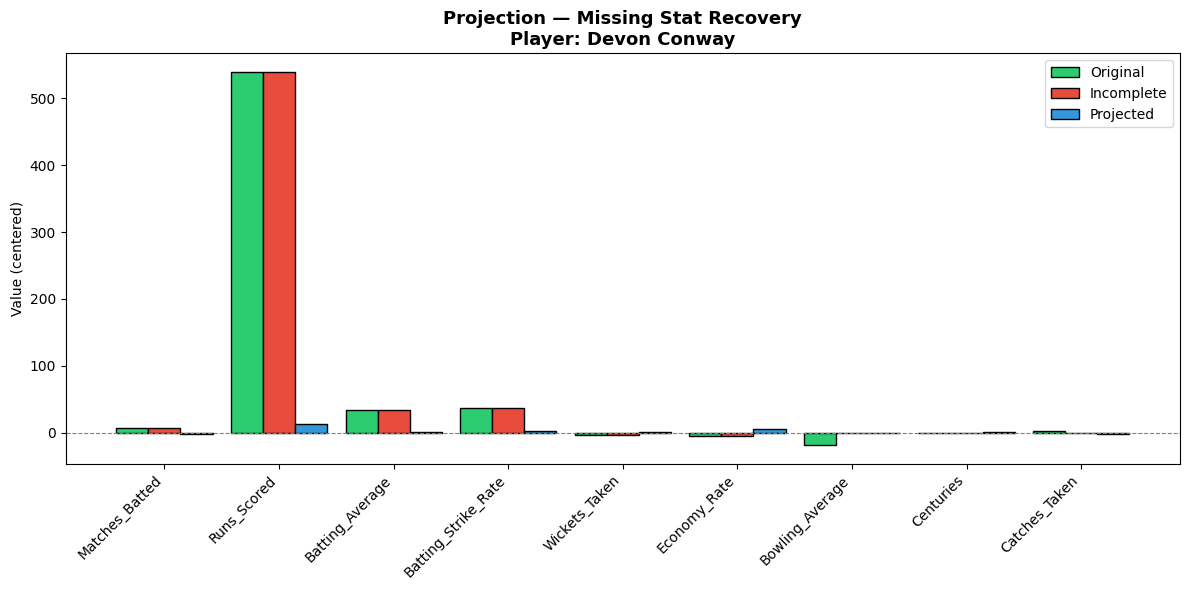

In [8]:
# --- Visualize Projection vs Original ---
import os
os.makedirs('../outputs', exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(feat_list))
width = 0.28

ax.bar(x - width, full_stats,        width, label='Original',       color='#2ecc71', edgecolor='black')
ax.bar(x,         incomplete_stats,  width, label='Incomplete',      color='#e74c3c', edgecolor='black')
ax.bar(x + width, projected_stats,   width, label='Projected',       color='#3498db', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(feat_list, rotation=45, ha='right')
ax.set_title(f'Projection — Missing Stat Recovery\nPlayer: {test_player_name}',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Value (centered)')
ax.legend()
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('../outputs/step6_projection_recovery.png', dpi=150)
plt.show()

In [9]:
# --- Find Similar Players ---
distances = np.array([
    np.linalg.norm(A_projected[i] - A_projected[test_player_idx])
    for i in range(len(player_names))
])
distances[test_player_idx] = np.inf
similar_idx = np.argsort(distances)[:5]

print(f"TOP 5 SIMILAR PLAYERS TO {test_player_name}")
print("=" * 50)
for rank_i, idx in enumerate(similar_idx):
    print(f"  {rank_i+1}. {player_names[idx]:<25} distance: {distances[idx]:.2f}")

TOP 5 SIMILAR PLAYERS TO Devon Conway
  1. KL Rahul                  distance: 0.23
  2. KL Rahul                  distance: 0.40
  3. David Warner              distance: 0.69
  4. David Warner              distance: 0.82
  5. Rishabh Pant              distance: 0.82


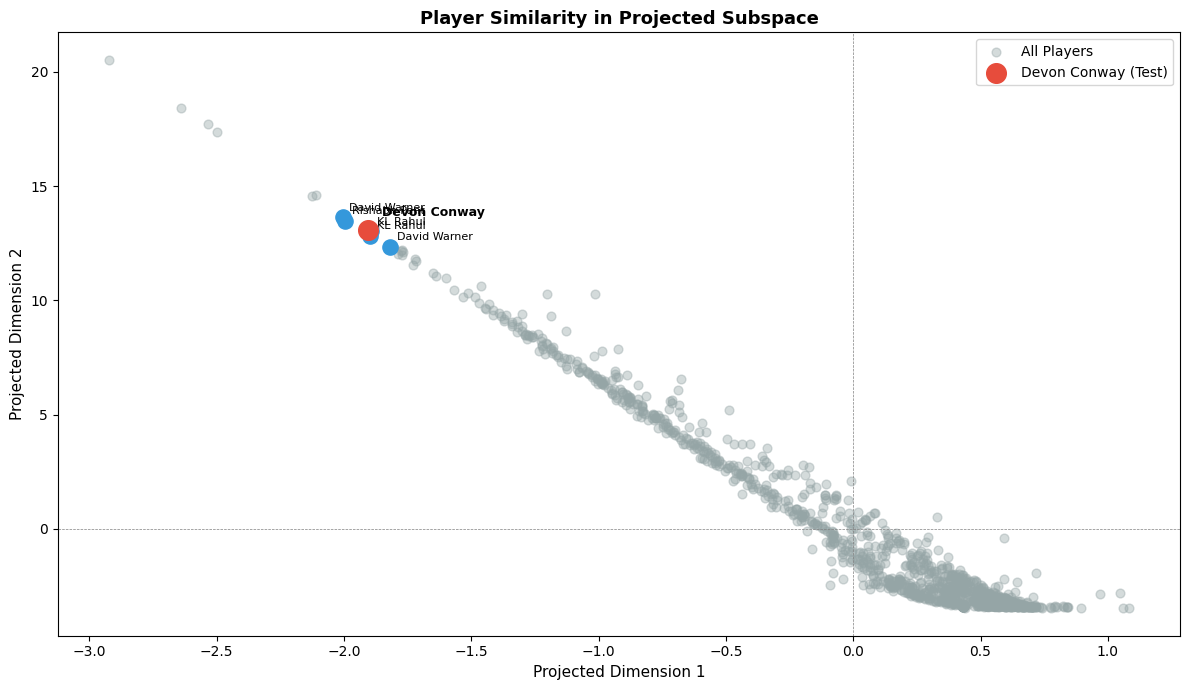

In [10]:
# --- Visualize Similarity in Projected Space ---
fig, ax = plt.subplots(figsize=(12, 7))

# Plot all players in projected 2D space
ax.scatter(A_projected[:, 0], A_projected[:, 1],
           alpha=0.4, color='#95a5a6', s=40, label='All Players')

# Highlight test player
ax.scatter(A_projected[test_player_idx, 0],
           A_projected[test_player_idx, 1],
           color='#e74c3c', s=200, zorder=5,
           label=f'{test_player_name} (Test)')
ax.annotate(test_player_name,
            (A_projected[test_player_idx, 0],
             A_projected[test_player_idx, 1]),
            fontsize=9, fontweight='bold',
            xytext=(10, 10), textcoords='offset points')

# Highlight similar players
for idx in similar_idx:
    ax.scatter(A_projected[idx, 0], A_projected[idx, 1],
               color='#3498db', s=120, zorder=4)
    ax.annotate(player_names[idx],
                (A_projected[idx, 0], A_projected[idx, 1]),
                fontsize=8, xytext=(5, 5),
                textcoords='offset points')

ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_xlabel('Projected Dimension 1', fontsize=11)
ax.set_ylabel('Projected Dimension 2', fontsize=11)
ax.set_title('Player Similarity in Projected Subspace',
             fontweight='bold', fontsize=13)
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/step6_player_similarity.png', dpi=150)
plt.show()

In [11]:
# --- Summary ---
print("=" * 50)
print("STEP 6 SUMMARY — Projection")
print("=" * 50)
print(f"""
Projection Matrix P = Q Qᵀ
  → Shape     : {P.shape}
  → Idempotent: P² = P ✓
  → Symmetric : P = Pᵀ ✓

What Projection Does:
  → Maps every player vector onto the performance subspace
  → Recovers missing stats using known performance patterns
  → Finds similar players via distance in projected space

Test Player  : {test_player_name}
Recovery Error: {recovery_error:.4f}
  → Lower error = better recovery from projection
""")

# --- Save for Step 7 ---
np.save('../data/A_projected.npy', A_projected)
np.save('../data/P_matrix.npy', P)

print("✅ Step 6 Complete!")
print("   → Ready for Step 7: Least Squares Prediction")

STEP 6 SUMMARY — Projection

Projection Matrix P = Q Qᵀ
  → Shape     : (9, 9)
  → Idempotent: P² = P ✓
  → Symmetric : P = Pᵀ ✓

What Projection Does:
  → Maps every player vector onto the performance subspace
  → Recovers missing stats using known performance patterns
  → Finds similar players via distance in projected space

Test Player  : Devon Conway
Recovery Error: 529.4663
  → Lower error = better recovery from projection

✅ Step 6 Complete!
   → Ready for Step 7: Least Squares Prediction
